# AG-HYPOPT · Trial 23

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twenty-two trials. Best: **trial_13** `cvm_fwhm` **0.0733** (sw 0.1910). The `cvm_fwhm` series (twelve
points, sw 0.18-0.38) has mean ~0.0781, std ~0.003, eleven of twelve under the KDE control (0.080328).
Every other family at matched sw is clearly above the control; the win is a gamma-channel, loss-FORM
effect and is small (~0.002) on the mean. Remaining trials refine the winner. No divergences. Phase
`trials` (22/5).


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_23'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (22/5 trials)
ID |     ei | params
 1 | 3.2441 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.20063383669421403}
 2 | 1.4090 | {"loss_family": "w1_2d", "sigma_weight": 0.18553122579448816}
 3 | 2.2977 | {"loss_family": "energy_2d", "sigma_weight": 0.19701792728573156}
 4 | 3.0398 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.19177640255156353}
 5 | 2.3461 | {"loss_family": "kde", "sigma_weight": 0.203205598234262}
 6 | 2.3396 | {"loss_family": "w1_fwhm", "sigma_weight": 0.2036780991523442}
 7 | 2.2682 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.2322952894899398}
 8 | 3.2195 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.2048600114920509}
 9 |      - | {"loss_family": "kde", "sigma_weight": 0.012823118470840722}
10 |      - | {"loss_family": "cvm_fwhm", "sigma_weight": 0.8283282979898389}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

EI again leads with `cvm_fwhm` basin points (candidates 1, 8, 4, 7). I follow the top-EI candidate 1
(`cvm_fwhm`, sw 0.2006). The non-`cvm_fwhm` candidates are families already known to be worse.

I choose candidate 1.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'cvm_fwhm', 'sigma_weight': 0.20063383669421403}
Running  1nW Trans05 ... 

μ 9.39 -> 5.44 | γ 8.5 -> 4.21 | NLL 158.45


Running  1nW Trans20 ... 

μ 17.32 -> 22.54 | γ 8.5 -> 5.94 | NLL 0.84


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 61.49 | γ 14.1 -> 13.93 | NLL 0.08


Running 3nW Trans100 ... 

μ 175.71 -> 93.80 | γ 14.1 -> 13.26 | NLL 16.63



Total: 7.8 min


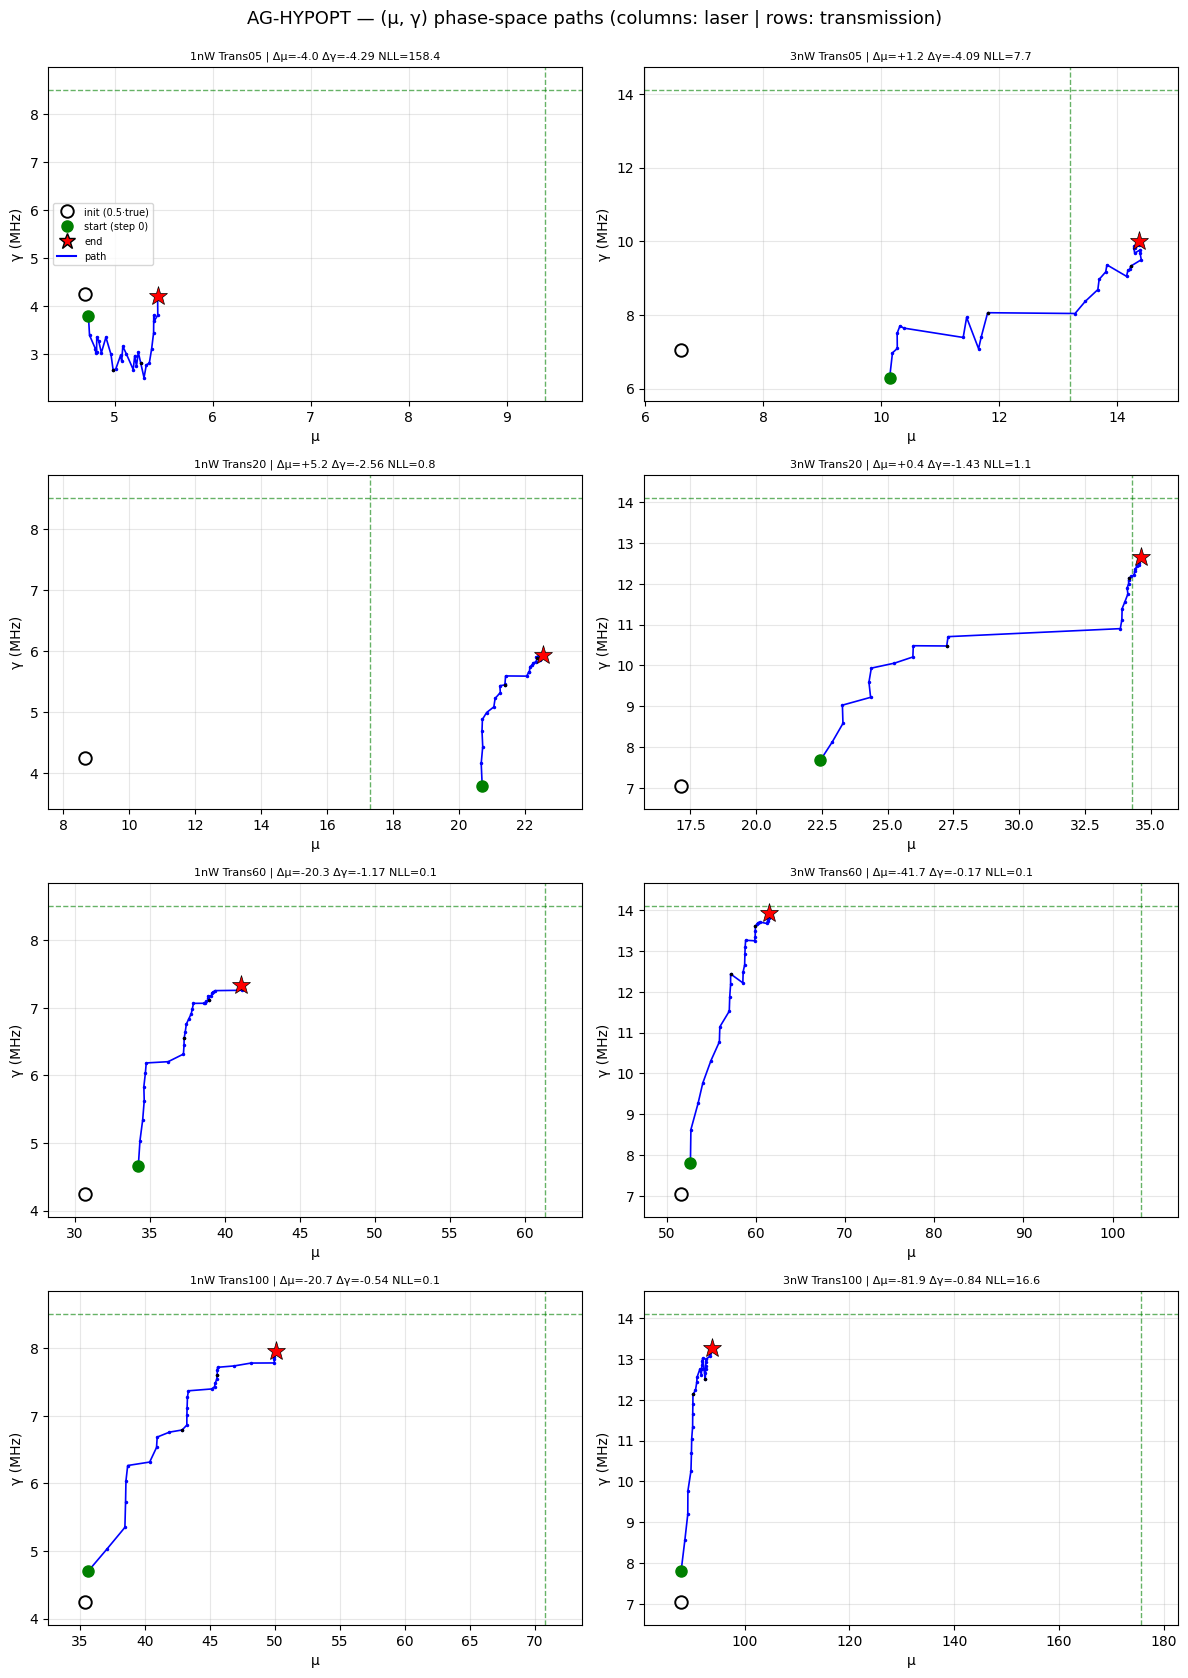

trial finished in 7.9 min
objective = 0.0777 ± 0.0209
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.44   -42.1 |     8.50    4.21   -50.4
1nW Trans20       17.32   22.54   +30.2 |     8.50    5.94   -30.2
1nW Trans60       61.37   41.11   -33.0 |     8.50    7.33   -13.7
1nW Trans100       70.82   50.07   -29.3 |     8.50    7.96    -6.4
3nW Trans05       13.20   14.38    +8.9 |    14.10   10.01   -29.0
3nW Trans20       34.28   34.64    +1.1 |    14.10   12.67   -10.2
3nW Trans60      103.20   61.49   -40.4 |    14.10   13.93    -1.2
3nW Trans100      175.71   93.80   -46.6 |    14.10   13.26    -5.9

weighted objective (T-graded, cap=1.0) = 0.0777 | diverged cells: 0
μ: RMSE 34.157 (rel 32.6%, bias -20.228) | γ: RMSE 2.400 (rel 24.1%, bias -1.885)


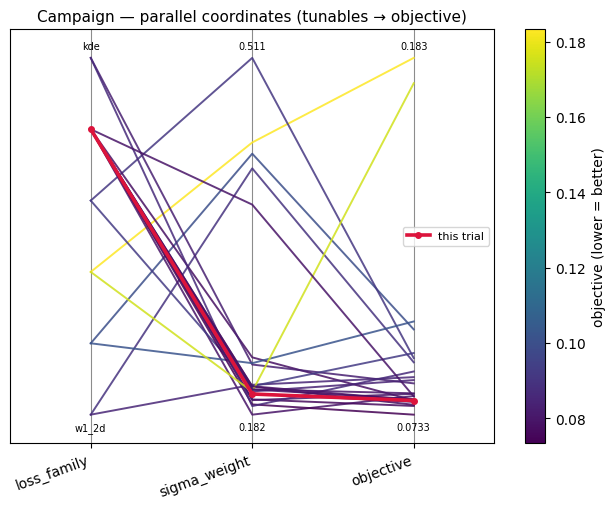

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'cvm_fwhm', sigma_weight: 0.2006}` (candidate 1, top EI).
Trial time 7.9 min, objective **0.0777 +/- 0.0209**, **0 diverged cells** - a basin replication.

**Basin statistics.** Thirteen `cvm_fwhm` points (sw 0.18-0.38): mean ~0.0780, std ~0.003; twelve of
thirteen under the KDE control (0.080328), only trial_19 (0.0840) above.

**Per-cell behaviour / aggregates.** Unchanged profile; mu RMSE 34.16 (rel 32.6 %, bias -20.23), gamma
RMSE 2.40 (rel 24.1 %, bias -1.89).

**Summary:** `cvm_fwhm` at sw 0.2006 gives 0.0777, keeping the family mean at ~0.0780 over thirteen draws
(twelve under the KDE control).
**Key insight:** The basin mean stays pinned at ~0.078; the winner's edge over the control is a small,
consistent ~0.002.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'cvm_fwhm at sigma_weight 0.2006 gives 0.0777, keeping the family mean at ~0.0780 over thirteen draws (twelve under the KDE control).'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'The basin mean stays pinned at ~0.078; the winner edge over the control is a small, consistent ~0.002.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_23 | current best: trial_13


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_24.ipynb. Open it and follow its cells from the top.
